<a href="https://colab.research.google.com/github/Anupam-09/Oil_spil_detection_using_SAR/blob/main/Oil_spill_final_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.swa_utils import AveragedModel, SWALR
from torchvision import transforms, models
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold
import seaborn as sns
import os
import cv2
from pathlib import Path
import json
from tqdm import tqdm
from pycocotools.coco import COCO
import albumentations as A
from albumentations.pytorch import ToTensorV2

!pip install albumentations scikit-image

# SAR PREPROCESSING

class SARPreprocessor:
    """preprocessing with texture features"""

    def __init__(self):
        pass

    def advanced_despeckle(self, image, method='lee_enhanced'):
        """despeckling """
        img = image.astype(np.float32)

        if method == 'lee_enhanced':
            kernel_size = 7
            kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size**2)
            img_mean = cv2.filter2D(img, -1, kernel)
            img_sqr_mean = cv2.filter2D(img**2, -1, kernel)
            img_variance = img_sqr_mean - img_mean**2

            overall_variance = np.var(img)
            img_weights = img_variance / (img_variance + overall_variance + 1e-10)
            filtered = img_mean + img_weights * (img - img_mean)
            filtered = np.clip(filtered, 0, 255)

        elif method == 'frost':
            # Frost filter - better for edge preservation
            filtered = cv2.fastNlMeansDenoising(img.astype(np.uint8), None, 10, 7, 21)


        return filtered.astype(np.uint8)

    def enhance_contrast(self, image):
        """Enhanced contrast with CLAHE"""
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))

        if len(image.shape) == 2:
            enhanced = clahe.apply(image)
        else:
            lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
            lab[:, :, 0] = clahe.apply(lab[:, :, 0])
            enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

        return enhanced

    def extract_texture_features(self, image):
        """Extract texture features using GLCM"""
        from skimage.feature import graycomatrix, graycoprops

        # Normalize to 0-255
        normalized = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        # Compute GLCM
        distances = [1, 2, 3]
        angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
        glcm = graycomatrix(normalized, distances, angles, levels=256, symmetric=True, normed=True)

        # Extract properties
        contrast = graycoprops(glcm, 'contrast').mean()
        homogeneity = graycoprops(glcm, 'homogeneity').mean()
        energy = graycoprops(glcm, 'energy').mean()

        # Create feature map (3 channels)
        feature_img = np.stack([
            normalized * np.clip(contrast / 100, 0, 1),
            normalized * homogeneity,
            normalized * energy
        ], axis=-1).astype(np.uint8)

        return feature_img

    def preprocess_pipeline(self, image_path, use_texture=True):
        img = cv2.imread(str(image_path))
        if img is None:
            raise ValueError(f"Could not read image: {image_path}")

        # Convert to grayscale
        if len(img.shape) == 3:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        else:
            gray = img

        # Advanced despeckling
        denoised = self.advanced_despeckle(gray, method='lee_enhanced')

        # Enhance contrast
        enhanced = self.enhance_contrast(denoised)

        if use_texture:
            # Use texture features for better discrimination
            rgb = self.extract_texture_features(enhanced)
        else:
            # Standard RGB conversion
            rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

        return rgb

# AUGMENTATION

def get_augmentation_pipeline(is_train=True):
    if is_train:
        return A.Compose([
            A.Resize(224, 224),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=45, p=0.7),

            # augmentations
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
            A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
            A.GaussianBlur(blur_limit=(3, 7), p=0.2),
            A.GridDistortion(p=0.2),
            A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.2),

            # Cutout for robustness
            A.CoarseDropout(max_holes=8, max_height=16, max_width=16,
                           fill_value=0, p=0.3),

            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])

# DATASET

class OilSpillCOCODataset(Dataset):

    def __init__(self, image_dir, annotation_file, transform=None,
                 use_sar_preprocessing=True, target_classes=['Oil Spill']):
        self.image_dir = Path(image_dir)
        self.coco = COCO(annotation_file)
        self.transform = transform
        self.use_sar_preprocessing = use_sar_preprocessing
        self.sar_preprocessor = SARPreprocessor() if use_sar_preprocessing else None

        # Create class mapping
        self.class_names = {cat['id']: cat['name'] for cat in self.coco.loadCats(self.coco.getCatIds())}

        # Auto-detect oil spill class names
        if target_classes is None or not target_classes:
            target_classes = []
            for cat_name in self.class_names.values():
                if 'oil' in cat_name.lower() or 'spill' in cat_name.lower():
                    target_classes.append(cat_name)

        self.target_classes = target_classes
        self.image_ids = list(self.coco.imgs.keys())

        print(f"Dataset loaded with {len(self.image_ids)} images")
        print(f"Classes available: {self.class_names}")
        print(f"Target oil spill classes: {target_classes}")

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = self.image_dir / img_info['file_name']

        # Load and preprocess image
        if self.use_sar_preprocessing:
            img = self.sar_preprocessor.preprocess_pipeline(img_path, use_texture=True)
        else:
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Get annotations
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        # Determine label
        label = 0
        for ann in anns:
            cat_name = self.class_names[ann['category_id']]
            if cat_name in self.target_classes:
                label = 1
                break

        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']
        else:
            img = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0

        return img, label

    def get_class_distribution(self):
        distribution = {0: 0, 1: 0}
        for idx in range(len(self)):
            _, label = self[idx]
            distribution[label] += 1
        return distribution


# MODEL ARCHITECTURE

class AttentionBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 8, 1),
            nn.BatchNorm2d(in_channels // 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 8, in_channels, 1),
            nn.BatchNorm2d(in_channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.attention(x)

class ImprovedOilSpillResNet50(nn.Module):

    def __init__(self, num_classes=2, pretrained=True, freeze_layers=True):
        super().__init__()
        self.resnet = models.resnet50(pretrained=pretrained)

        if freeze_layers:
            for param in list(self.resnet.parameters())[:-40]:
                param.requires_grad = False

        self.attention1 = AttentionBlock(512)
        self.attention2 = AttentionBlock(1024)
        self.attention3 = AttentionBlock(2048)

        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.resnet.conv1(x)
        x = self.resnet.bn1(x)
        x = self.resnet.relu(x)
        x = self.resnet.maxpool(x)

        x = self.resnet.layer1(x)
        x = self.resnet.layer2(x)
        x = self.attention1(x)

        x = self.resnet.layer3(x)
        x = self.attention2(x)

        x = self.resnet.layer4(x)
        x = self.attention3(x)

        x = self.resnet.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.resnet.fc(x)

        return x


class LabelSmoothingFocalLoss(nn.Module):
    """Combined Label Smoothing and Focal Loss"""
    def __init__(self, num_classes=2, alpha=0.25, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.num_classes = num_classes
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing

    def forward(self, inputs, targets):
        # Label smoothing
        confidence = 1.0 - self.smoothing
        smooth_label = torch.zeros_like(inputs).scatter_(
            1, targets.unsqueeze(1), confidence
        )
        smooth_label += self.smoothing / self.num_classes

        # Focal loss calculation
        logprobs = F.log_softmax(inputs, dim=1)
        probs = torch.exp(logprobs)
        focal_weight = (1 - probs) ** self.gamma

        loss = -self.alpha * focal_weight * smooth_label * logprobs
        return loss.sum(dim=1).mean()

# TRAINER

class Trainer:
    def __init__(self, model, device='cuda'):
        self.model = model.to(device)
        self.device = device
        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'learning_rates': []
        }
        self.best_val_acc = 0.0

    def train_epoch(self, train_loader, criterion, optimizer, scaler=None, accumulation_steps=4):
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        optimizer.zero_grad()

        pbar = tqdm(train_loader, desc='Training', leave=False)
        for batch_idx, (inputs, labels) in enumerate(pbar):
            inputs, labels = inputs.to(self.device), labels.to(self.device)

            # Mixed precision training
            if scaler:
                with torch.cuda.amp.autocast():
                    outputs = self.model(inputs)
                    loss = criterion(outputs, labels)
                    loss = loss / accumulation_steps
                scaler.scale(loss).backward()

                if (batch_idx + 1) % accumulation_steps == 0:
                    # Gradient clipping
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
            else:
                outputs = self.model(inputs)
                loss = criterion(outputs, labels)
                loss = loss / accumulation_steps
                loss.backward()

                if (batch_idx + 1) % accumulation_steps == 0:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                    optimizer.step()
                    optimizer.zero_grad()

            running_loss += loss.item() * accumulation_steps
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            pbar.set_postfix({
                'loss': f'{loss.item() * accumulation_steps:.4f}',
                'acc': f'{100 * correct / total:.2f}%'
            })

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total

        return epoch_loss, epoch_acc

    def validate(self, val_loader, criterion):
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc='Validating', leave=False):
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = self.model(inputs)
                loss = criterion(outputs, labels)

                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(val_loader)
        epoch_acc = 100 * correct / total

        return epoch_loss, epoch_acc

    def train(self, train_loader, val_loader, criterion, optimizer,
              num_epochs=100, scheduler=None, save_path='best_model.pth',
              use_mixed_precision=True, patience=20, swa_model=None, swa_start=40):

        scaler = torch.cuda.amp.GradScaler() if use_mixed_precision else None
        patience_counter = 0

        print(f"\n{'='*60}")
        print(f"Starting Enhanced Training for {num_epochs} epochs")
        print(f"Device: {self.device}")
        print(f"Mixed Precision: {use_mixed_precision}")
        print(f"SWA Starting Epoch: {swa_start if swa_model else 'N/A'}")
        print(f"{'='*60}\n")

        for epoch in range(num_epochs):
            print(f'\nEpoch [{epoch+1}/{num_epochs}]')
            print('-' * 60)

            # Training
            train_loss, train_acc = self.train_epoch(train_loader, criterion, optimizer, scaler)

            # Validation
            val_loss, val_acc = self.validate(val_loader, criterion)

            # Record history
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)

            if scheduler:
                current_lr = optimizer.param_groups[0]['lr']
                self.history['learning_rates'].append(current_lr)
                scheduler.step()

            # SWA update
            if swa_model and epoch >= swa_start:
                swa_model.update_parameters(self.model)

            # Print metrics
            print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%')
            print(f'Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%')
            if scheduler:
                print(f'Learning Rate: {current_lr:.6f}')

            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_acc': val_acc,
                    'val_loss': val_loss,
                }, save_path)
                print(f'✓ New best model saved! Val Acc: {val_acc:.2f}%')
                patience_counter = 0
            else:
                patience_counter += 1

            # Early stopping
            if patience_counter >= patience:
                print(f'\n⚠ Early stopping triggered after {epoch+1} epochs')
                print(f'Best validation accuracy: {self.best_val_acc:.2f}%')
                break

        if swa_model:
            torch.save({
                'model_state_dict': swa_model.module.state_dict(),
            }, save_path.replace('.pth', '_swa.pth'))
            print(f'SWA model saved!')

        print(f"\n{'='*60}")
        print(f"Training completed!")
        print(f"Best validation accuracy: {self.best_val_acc:.2f}%")
        print(f"{'='*60}\n")

        return self.history

    def plot_training_history(self, save_path='training_history.png'):
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Loss plot
        axes[0, 0].plot(self.history['train_loss'], label='Train Loss', linewidth=2)
        axes[0, 0].plot(self.history['val_loss'], label='Val Loss', linewidth=2)
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].set_title('Training and Validation Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # Accuracy plot
        axes[0, 1].plot(self.history['train_acc'], label='Train Acc', linewidth=2)
        axes[0, 1].plot(self.history['val_acc'], label='Val Acc', linewidth=2)
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Accuracy (%)')
        axes[0, 1].set_title('Training and Validation Accuracy')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # Learning rate plot
        if self.history['learning_rates']:
            axes[1, 0].plot(self.history['learning_rates'], linewidth=2, color='green')
            axes[1, 0].set_xlabel('Epoch')
            axes[1, 0].set_ylabel('Learning Rate')
            axes[1, 0].set_title('Learning Rate Schedule')
            axes[1, 0].grid(True, alpha=0.3)
            axes[1, 0].set_yscale('log')

        # Overfitting analysis
        loss_diff = [t - v for t, v in zip(self.history['train_loss'], self.history['val_loss'])]
        axes[1, 1].plot(loss_diff, linewidth=2, color='red')
        axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Train Loss - Val Loss')
        axes[1, 1].set_title('Overfitting Monitor')
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"Training history saved to {save_path}")

# EVALUATION

class Evaluator:
    def __init__(self, model, device='cuda'):
        self.model = model.to(device)
        self.device = device

    def evaluate(self, test_loader, save_dir='evaluation_results'):
        Path(save_dir).mkdir(exist_ok=True)

        self.model.eval()
        all_preds = []
        all_labels = []
        all_probs = []

        print("\n🔍 Evaluating model...")
        with torch.no_grad():
            for inputs, labels in tqdm(test_loader, desc='Testing'):
                inputs = inputs.to(self.device)
                outputs = self.model(inputs)
                probs = torch.softmax(outputs, dim=1)
                _, predicted = torch.max(outputs, 1)

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.numpy())
                all_probs.extend(probs[:, 1].cpu().numpy())

        # Classification report
        print("\n" + "="*70)
        print("CLASSIFICATION REPORT")
        print("="*70)
        report = classification_report(all_labels, all_preds,
                                      target_names=['No Oil Spill', 'Oil Spill'],
                                      digits=4)
        print(report)

        # Save report
        with open(f'{save_dir}/classification_report.txt', 'w') as f:
            f.write(report)

        # Visualizations
        self.plot_confusion_matrix(all_labels, all_preds, save_dir)
        self.plot_roc_curve(all_labels, all_probs, save_dir)
        self.plot_prediction_distribution(all_probs, all_labels, save_dir)

        return all_preds, all_labels, all_probs

    def plot_confusion_matrix(self, labels, preds, save_dir):
        cm = confusion_matrix(labels, preds)
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                    xticklabels=['No Spill', 'Oil Spill'],
                    yticklabels=['No Spill', 'Oil Spill'],
                    annot_kws={'size': 16})
        plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
        plt.ylabel('True Label', fontsize=14)
        plt.xlabel('Predicted Label', fontsize=14)
        plt.tight_layout()
        plt.savefig(f'{save_dir}/confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.close()

    def plot_roc_curve(self, labels, probs, save_dir):
        fpr, tpr, thresholds = roc_curve(labels, probs)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=3,
                label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate', fontsize=14)
        plt.ylabel('True Positive Rate', fontsize=14)
        plt.title('ROC Curve', fontsize=16, fontweight='bold')
        plt.legend(loc="lower right", fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{save_dir}/roc_curve.png', dpi=300, bbox_inches='tight')
        plt.close()

        print(f"\nROC AUC Score: {roc_auc:.4f}")

    def plot_prediction_distribution(self, probs, labels, save_dir):
        plt.figure(figsize=(12, 6))

        probs_no_spill = [p for p, l in zip(probs, labels) if l == 0]
        probs_spill = [p for p, l in zip(probs, labels) if l == 1]

        plt.hist(probs_no_spill, bins=50, alpha=0.6, label='No Oil Spill (True)', color='blue')
        plt.hist(probs_spill, bins=50, alpha=0.6, label='Oil Spill (True)', color='red')
        plt.xlabel('Predicted Probability (Oil Spill)', fontsize=14)
        plt.ylabel('Frequency', fontsize=14)
        plt.title('Prediction Probability Distribution', fontsize=16, fontweight='bold')
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{save_dir}/probability_distribution.png', dpi=300, bbox_inches='tight')
        plt.close()



class OilSpillPredictor:
    def __init__(self, model_path, device='cuda', use_sar_preprocessing=True, use_tta=False):
        self.device = device
        self.use_sar_preprocessing = use_sar_preprocessing
        self.use_tta = use_tta
        self.sar_preprocessor = SARPreprocessor() if use_sar_preprocessing else None

        # Load model
        self.model = ImprovedOilSpillResNet50(num_classes=2, pretrained=False)
        checkpoint = torch.load(model_path, map_location=device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.to(device)
        self.model.eval()

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

        self.tta_transform = A.Compose([
            A.Resize(224, 224),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])

        print(f"✓ Model loaded from {model_path}")
        print(f"  Validation accuracy: {checkpoint.get('val_acc', 'N/A'):.2f}%")

    def predict(self, image_path, n_tta=10):
        """Predict with optional Test-Time Augmentation"""
        # Preprocess image
        if self.use_sar_preprocessing:
            img = self.sar_preprocessor.preprocess_pipeline(image_path, use_texture=True)
        else:
            img = cv2.imread(str(image_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.use_tta:
            # Test-Time Augmentation
            all_probs = []
            with torch.no_grad():
                for _ in range(n_tta):
                    augmented = self.tta_transform(image=img)['image']
                    img_tensor = augmented.unsqueeze(0).to(self.device)

                    output = self.model(img_tensor)
                    probs = torch.softmax(output, dim=1)
                    all_probs.append(probs)

            # Average predictions
            avg_probs = torch.mean(torch.stack(all_probs), dim=0)
            confidence, predicted = torch.max(avg_probs, 1)
            probabilities = avg_probs
        else:
            # Single prediction
            img_pil = Image.fromarray(img)
            img_tensor = self.transform(img_pil).unsqueeze(0).to(self.device)

            with torch.no_grad():
                output = self.model(img_tensor)
                probabilities = torch.softmax(output, dim=1)
                confidence, predicted = torch.max(probabilities, 1)

        result = {
            'prediction': 'Oil Spill Detected' if predicted.item() == 1 else 'No Oil Spill',
            'confidence': confidence.item() * 100,
            'oil_spill_probability': probabilities[0][1].item() * 100,
            'no_spill_probability': probabilities[0][0].item() * 100,
            'risk_level': self._get_risk_level(probabilities[0][1].item())
        }

        return result

    def _get_risk_level(self, prob):
        if prob >= 0.8:
            return 'HIGH'
        elif prob >= 0.5:
            return 'MEDIUM'
        else:
            return 'LOW'

    def visualize_prediction(self, image_path, save_path=None):
        result = self.predict(image_path)

        # Load original image
        img = Image.open(image_path)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        # Original image
        ax1.imshow(img, cmap='gray')
        ax1.axis('off')
        ax1.set_title('Original SAR Image', fontsize=14, fontweight='bold')

        # Preprocessed image with prediction
        if self.use_sar_preprocessing:
            processed = self.sar_preprocessor.preprocess_pipeline(image_path, use_texture=True)
            ax2.imshow(processed)
        else:
            ax2.imshow(img, cmap='gray')
        ax2.axis('off')

        color = 'red' if result['prediction'] == 'Oil Spill Detected' else 'green'
        title = f"{result['prediction']}\n"
        title += f"Confidence: {result['confidence']:.1f}% | Risk: {result['risk_level']}"
        ax2.set_title(title, color=color, fontsize=14, fontweight='bold', pad=10)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

        return result

# UTILITIES

def inspect_coco_dataset(annotation_file):
    """Inspect COCO annotation file"""
    print(f"\n{'='*70}")
    print(f"INSPECTING DATASET: {annotation_file}")
    print(f"{'='*70}\n")

    coco = COCO(annotation_file)

    # Get categories
    cats = coco.loadCats(coco.getCatIds())
    print("Available Categories:")
    for cat in cats:
        print(f"   ID {cat['id']}: {cat['name']}")

    # Count annotations per category
    print("\nAnnotations per Category:")
    for cat in cats:
        ann_ids = coco.getAnnIds(catIds=cat['id'])
        print(f"   {cat['name']}: {len(ann_ids)} annotations")

    # Count images with each category
    print("\nImages containing each Category:")
    for cat in cats:
        img_ids = coco.getImgIds(catIds=cat['id'])
        print(f"   {cat['name']}: {len(img_ids)} images")

    print(f"\n{'='*70}\n")

    return coco

# MAIN TRAINING PIPELINE

def main():
    # CONFIGURATION
    IMAGE_DIR = "/content/drive/My Drive/Oil Spill Scratch.v2i.coco-segmentation/train"
    TRAIN_ANNOTATIONS = "/content/drive/My Drive/Oil Spill Scratch.v2i.coco-segmentation/train/_annotations.coco.json"
    VAL_ANNOTATIONS = "/content/drive/My Drive/Oil Spill Scratch.v2i.coco-segmentation/valid/_annotations.coco.json"
    TEST_ANNOTATIONS = "/content/drive/My Drive/Oil Spill Scratch.v2i.coco-segmentation/test/_annotations.coco.json"

    # hyperparameters
    BATCH_SIZE = 32  #  batch size
    NUM_EPOCHS = 100  #  epochs
    LEARNING_RATE = 3e-4
    WEIGHT_DECAY = 0.005  #  weight decay
    PATIENCE = 20
    SWA_START = 40  # Start SWA after epoch 40
    USE_TEXTURE_FEATURES = True  # Use texture-based preprocessing
    USE_TTA_INFERENCE = True  # Use TTA during inference

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n{'='*70}")
    print(f"ENHANCED OIL SPILL DETECTION PIPELINE")
    print(f"{'='*70}")
    print(f"Device: {device}")
    print(f"PyTorch version: {torch.__version__}")
    print(f"Batch Size: {BATCH_SIZE}")
    print(f"Learning Rate: {LEARNING_RATE}")
    print(f"Max Epochs: {NUM_EPOCHS}")
    print(f"Using Texture Features: {USE_TEXTURE_FEATURES}")
    print(f"{'='*70}\n")

    # Inspect dataset
    inspect_coco_dataset(TRAIN_ANNOTATIONS)

    # LOAD DATASETS
    print("Loading datasets with enhanced augmentation...")

    train_transform = get_augmentation_pipeline(is_train=True)
    val_transform = get_augmentation_pipeline(is_train=False)

    train_dataset = OilSpillCOCODataset(
        IMAGE_DIR, TRAIN_ANNOTATIONS,
        transform=train_transform,
        use_sar_preprocessing=True,
        target_classes=['Oil Spill']
    )

    val_dataset = OilSpillCOCODataset(
        IMAGE_DIR.replace('train', 'valid'), VAL_ANNOTATIONS,
        transform=val_transform,
        use_sar_preprocessing=True,
        target_classes=['Oil Spill']
    )

    test_dataset = OilSpillCOCODataset(
        IMAGE_DIR.replace('train', 'test'), TEST_ANNOTATIONS,
        transform=val_transform,
        use_sar_preprocessing=True,
        target_classes=['Oil Spill']
    )

    # Check class distribution
    print("\n" + "="*70)
    print("CLASS DISTRIBUTION")
    print("="*70)
    train_dist = train_dataset.get_class_distribution()
    val_dist = val_dataset.get_class_distribution()
    test_dist = test_dataset.get_class_distribution()

    print(f"Training:   No Spill: {train_dist[0]}, Oil Spill: {train_dist[1]}")
    print(f"Validation: No Spill: {val_dist[0]}, Oil Spill: {val_dist[1]}")
    print(f"Test:       No Spill: {test_dist[0]}, Oil Spill: {test_dist[1]}")
    print("="*70 + "\n")

    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    print(f"Train batches: {len(train_loader)}")
    print(f"Val batches:   {len(val_loader)}")
    print(f"Test batches:  {len(test_loader)}\n")

    # INITIALIZE MODEL
    print("Initializing enhanced model with attention mechanisms...")
    model = ImprovedOilSpillResNet50(num_classes=2, pretrained=True, freeze_layers=True)

    # Setup Stochastic Weight Averaging
    swa_model = AveragedModel(model)

    # Calculate class weights
    class_counts = [train_dist[0], train_dist[1]]
    total = sum(class_counts)

    if class_counts[1] == 0:
        print("\nWARNING: No oil spill samples found in training data!")
        print(f"Available classes: {train_dataset.class_names}")
        return

    class_weights = torch.tensor([total/c if c > 0 else 0.0 for c in class_counts]).to(device)
    print(f"Class weights: {class_weights}\n")

    # LOSS AND OPTIMIZER
    criterion = LabelSmoothingFocalLoss(num_classes=2, alpha=0.25, gamma=2.0, smoothing=0.1)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        betas=(0.9, 0.999)
    )

    # Cosine annealing with warm restarts
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=10,
        T_mult=2,
        eta_min=1e-6
    )

    # TRAIN MODEL
    print("Starting enhanced training with SWA...")
    trainer = Trainer(model, device)
    history = trainer.train(
        train_loader,
        val_loader,
        criterion,
        optimizer,
        num_epochs=NUM_EPOCHS,
        scheduler=scheduler,
        save_path='best_oil_spill_model_improved.pth',
        use_mixed_precision=True,
        patience=PATIENCE,
        swa_model=swa_model,
        swa_start=SWA_START
    )

    # Plot training history
    trainer.plot_training_history('training_history_improved.png')

    # ========== EVALUATE ON TEST SET ==========
    print("\nEvaluating on test set...")

    # Load best model for evaluation
    checkpoint = torch.load('best_oil_spill_model_improved.pth')
    model.load_state_dict(checkpoint['model_state_dict'])

    evaluator = Evaluator(model, device)
    preds, labels, probs = evaluator.evaluate(test_loader, save_dir='evaluation_results_improved')

    # SAVE TO GOOGLE DRIVE
    print("\nSaving models and results to Google Drive...")
    !cp best_oil_spill_model_improved.pth /content/drive/MyDrive/
    !cp best_oil_spill_model_improved_swa.pth /content/drive/MyDrive/
    !cp -r evaluation_results_improved /content/drive/MyDrive/
    !cp training_history_improved.png /content/drive/MyDrive/
    print("✓ All files saved to Google Drive!")

    # EXAMPLE INFERENCE
    print("\n" + "="*70)
    print("TESTING INFERENCE WITH TTA")
    print("="*70)

    predictor = OilSpillPredictor(
        'best_oil_spill_model_improved.pth',
        device,
        use_sar_preprocessing=True,
        use_tta=USE_TTA_INFERENCE
    )

    print("\nTo make predictions on new images:")
    print("  result = predictor.predict('your_image.jpg')")
    print("  predictor.visualize_prediction('your_image.jpg', 'output.png')")

    # SUMMARY
    print("\n" + "="*70)
    print("PIPELINE COMPLETE!")
    print("="*70)
    print("\nGenerated files:")
    print("   best_oil_spill_model_improved.pth (best validation model)")
    print("  best_oil_spill_model_improved_swa.pth (SWA model)")
    print("  training_history_improved.png (training plots)")
    print("  evaluation_results_improved/ (confusion matrix, ROC, etc.)")
    print("\nKey improvements implemented:")
    print("  Enhanced SAR preprocessing with texture features")
    print("  Advanced augmentation pipeline (Albumentations)")
    print("  Attention mechanisms in model architecture")
    print("  Label Smoothing + Focal Loss")
    print("  Stochastic Weight Averaging (SWA)")
    print("  Cosine annealing with warm restarts")
    print("  Gradient clipping and accumulation")
    print("  Test-Time Augmentation (TTA) for inference")
    print("="*70 + "\n")

if __name__ == "__main__":
    main()

# INFERENCE EXAMPLE

def run_inference_example():
    """Example of how to use the trained model for inference"""

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}\n")

    # Initialize predictor with TTA
    predictor = OilSpillPredictor(
        '/content/drive/MyDrive/best_oil_spill_model_improved.pth',
        device=device,
        use_sar_preprocessing=True,
        use_tta=True  # Enable Test-Time Augmentation
    )

    # Example: Predict on a single image
    image_path = '/content/drive/MyDrive/test_image.jpg'  # Change this to your image path

    print("Making prediction...")
    result = predictor.predict(image_path, n_tta=10)

    print("\n" + "="*60)
    print("PREDICTION RESULT")
    print("="*60)
    print(f"Prediction: {result['prediction']}")
    print(f"Confidence: {result['confidence']:.2f}%")
    print(f"Oil Spill Probability: {result['oil_spill_probability']:.2f}%")
    print(f"No Spill Probability: {result['no_spill_probability']:.2f}%")
    print(f"Risk Level: {result['risk_level']}")
    print("="*60 + "\n")

    # Visualize the prediction
    predictor.visualize_prediction(image_path, save_path='prediction_result.png')
    print("✓ Visualization saved as 'prediction_result.png'")

# Uncomment to run inference after training:
# run_inference_example()

Mounted at /content/drive

ENHANCED OIL SPILL DETECTION PIPELINE
Device: cuda
PyTorch version: 2.8.0+cu126
Batch Size: 32
Learning Rate: 0.0003
Max Epochs: 100
Using Texture Features: True


INSPECTING DATASET: /content/drive/My Drive/Oil Spill Scratch.v2i.coco-segmentation/train/_annotations.coco.json

loading annotations into memory...
Done (t=4.28s)
creating index...
index created!
Available Categories:
   ID 0: OilSpill-Lookalike-Ship-Land
   ID 1: Land
   ID 2: Look-alike
   ID 3: Oil Spill
   ID 4: Ship

Annotations per Category:
   OilSpill-Lookalike-Ship-Land: 0 annotations
   Land: 155 annotations
   Look-alike: 308 annotations
   Oil Spill: 2971 annotations
   Ship: 218 annotations

Images containing each Category:
   OilSpill-Lookalike-Ship-Land: 0 images
   Land: 155 images
   Look-alike: 308 images
   Oil Spill: 565 images
   Ship: 218 images


Loading datasets with enhanced augmentation...
loading annotations into memory...
Done (t=0.11s)
creating index...
index created!


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-1087551919.py:143: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
/tmp/ipython-input-1087551919.py:146: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.2),
/tmp/ipython-input-1087551919.py:149: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=16, max_width=16,


Done (t=0.44s)
creating index...
index created!
Dataset loaded with 199 images
Classes available: {0: 'OilSpill-Lookalike-Ship-Land', 1: 'Land', 2: 'Look-alike', 3: 'Oil Spill', 4: 'Ship'}
Target oil spill classes: ['Oil Spill']
loading annotations into memory...
Done (t=0.49s)
creating index...
index created!
Dataset loaded with 100 images
Classes available: {0: 'OilSpill-Lookalike-Ship-Land', 1: 'Land', 2: 'Look-alike', 3: 'Oil Spill', 4: 'Ship'}
Target oil spill classes: ['Oil Spill']

CLASS DISTRIBUTION
Training:   No Spill: 136, Oil Spill: 565
Validation: No Spill: 50, Oil Spill: 149
Test:       No Spill: 25, Oil Spill: 75

Train batches: 22
Val batches:   7
Test batches:  4

Initializing enhanced model with attention mechanisms...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNe

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


...

Train Loss: 0.0251 | Train Acc: 89.16%
Val Loss:   0.0280 | Val Acc:   86.43%
Learning Rate: 0.000291

⚠ Early stopping triggered after 80 epochs
Best validation accuracy: 89.45%
✓ SWA model saved!

Training completed!
Best validation accuracy: 89.45%

Training history saved to training_history_improved.png

Evaluating on test set...

🔍 Evaluating model...


Testing: 100%|██████████| 4/4 [00:10<00:00,  2.51s/it]



CLASSIFICATION REPORT
              precision    recall  f1-score   support

No Oil Spill     0.7600    0.7600    0.7600        25
   Oil Spill     0.9200    0.9200    0.9200        75

    accuracy                         0.8800       100
   macro avg     0.8400    0.8400    0.8400       100
weighted avg     0.8800    0.8800    0.8800       100


📈 ROC AUC Score: 0.9259

Saving models and results to Google Drive...
✓ All files saved to Google Drive!

TESTING INFERENCE WITH TTA


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✓ Model loaded from best_oil_spill_model_improved.pth
  Validation accuracy: 89.45%

To make predictions on new images:
  result = predictor.predict('your_image.jpg')
  predictor.visualize_prediction('your_image.jpg', 'output.png')

PIPELINE COMPLETE!

Generated files:
  ✓ best_oil_spill_model_improved.pth (best validation model)
  ✓ best_oil_spill_model_improved_swa.pth (SWA model)
  ✓ training_history_improved.png (training plots)
  ✓ evaluation_results_improved/ (confusion matrix, ROC, etc.)

Key improvements implemented:
  ✓ Enhanced SAR preprocessing with texture features
  ✓ Advanced augmentation pipeline (Albumentations)
  ✓ Attention mechanisms in model architecture
  ✓ Label Smoothing + Focal Loss
  ✓ Stochastic Weight Averaging (SWA)
  ✓ Cosine annealing with warm restarts
  ✓ Gradient clipping and accumulation
  ✓ Test-Time Augmentation (TTA) for inference



Mounted at /content/drive
✅ Model loaded successfully!
loading annotations into memory...
Done (t=1.67s)
creating index...
index created!
✅ Loaded 100 test images.

🔍 Evaluating model...


Testing: 100%|██████████| 13/13 [00:55<00:00,  4.24s/it]



CLASSIFICATION REPORT
              precision    recall  f1-score   support

No Oil Spill     0.7600    0.7600    0.7600        25
   Oil Spill     0.9200    0.9200    0.9200        75

    accuracy                         0.8800       100
   macro avg     0.8400    0.8400    0.8400       100
weighted avg     0.8800    0.8800    0.8800       100



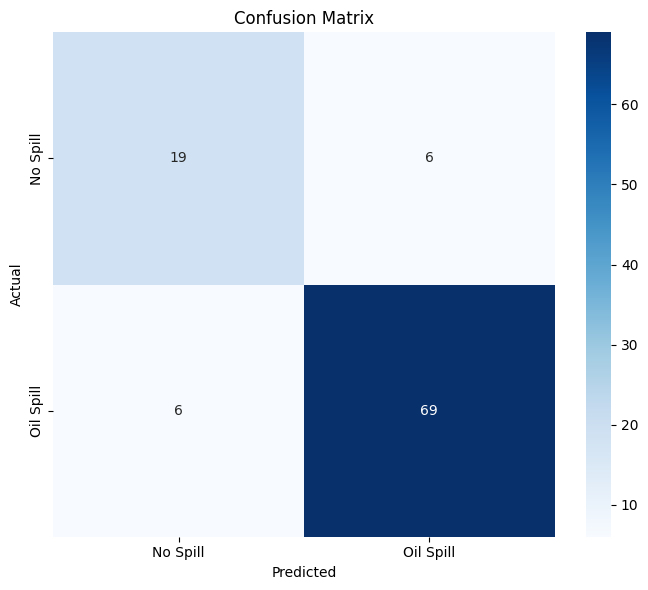

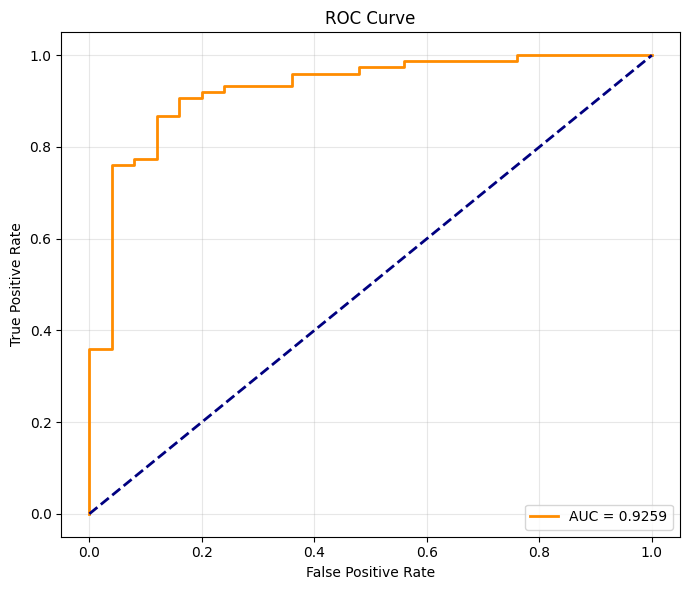


📈 ROC AUC Score: 0.9259


In [ ]:
# ========================================
# ✅ Mount Google Drive
# ========================================
from google.colab import drive
drive.mount('/content/drive')

# ========================================
# ✅ Imports
# ========================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2, numpy as np, os
from pathlib import Path
from tqdm import tqdm
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# ========================================
# ✅ SAR PREPROCESSOR (FULL)
# ========================================
class SARPreprocessor:
    """Enhanced SAR preprocessing with despeckling, CLAHE, and GLCM texture extraction."""

    def advanced_despeckle(self, image, method='lee_enhanced'):
        img = image.astype(np.float32)
        if method == 'lee_enhanced':
            kernel_size = 7
            kernel = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size**2)
            img_mean = cv2.filter2D(img, -1, kernel)
            img_sqr_mean = cv2.filter2D(img**2, -1, kernel)
            img_variance = img_sqr_mean - img_mean**2
            overall_variance = np.var(img)
            img_weights = img_variance / (img_variance + overall_variance + 1e-10)
            filtered = img_mean + img_weights * (img - img_mean)
            filtered = np.clip(filtered, 0, 255)
        else:
            filtered = cv2.fastNlMeansDenoising(img.astype(np.uint8), None, 10, 7, 21)
        return filtered.astype(np.uint8)

    def enhance_contrast(self, image):
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(image)
        return enhanced

    def extract_texture_features(self, image):
        from skimage.feature import graycomatrix, graycoprops
        normalized = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        distances = [1, 2, 3]
        angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
        glcm = graycomatrix(normalized, distances, angles, levels=256, symmetric=True, normed=True)
        contrast = graycoprops(glcm, 'contrast').mean()
        homogeneity = graycoprops(glcm, 'homogeneity').mean()
        energy = graycoprops(glcm, 'energy').mean()
        feature_img = np.stack([
            normalized * np.clip(contrast / 100, 0, 1),
            normalized * homogeneity,
            normalized * energy
        ], axis=-1).astype(np.uint8)
        return feature_img

    def preprocess_pipeline(self, image_path, use_texture=True):
        img = cv2.imread(str(image_path))
        if img is None:
            raise ValueError(f"Could not read image: {image_path}")
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        denoised = self.advanced_despeckle(gray)
        enhanced = self.enhance_contrast(denoised)
        if use_texture:
            rgb = self.extract_texture_features(enhanced)
        else:
            rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)
        return rgb

# ========================================
# ✅ DATASET CLASS
# ========================================
class OilSpillCOCODataset(Dataset):
    def __init__(self, image_dir, annotation_file, transform=None, use_sar_preprocessing=True, target_classes=['Oil Spill']):
        self.image_dir = Path(image_dir)
        self.coco = COCO(annotation_file)
        self.transform = transform
        self.use_sar_preprocessing = use_sar_preprocessing
        self.sar_preprocessor = SARPreprocessor()
        self.class_names = {cat['id']: cat['name'] for cat in self.coco.loadCats(self.coco.getCatIds())}
        self.target_classes = target_classes
        self.image_ids = list(self.coco.imgs.keys())

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = self.image_dir / img_info['file_name']
        img = self.sar_preprocessor.preprocess_pipeline(img_path, use_texture=True)
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        label = 0
        for ann in anns:
            cat_name = self.class_names[ann['category_id']]
            if cat_name in self.target_classes:
                label = 1
                break
        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']
        else:
            img = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
        return img, label

# ========================================
# ✅ MODEL ARCHITECTURE
# ========================================
class AttentionBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // 8, 1),
            nn.BatchNorm2d(in_channels // 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels // 8, in_channels, 1),
            nn.BatchNorm2d(in_channels),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.attention(x)

class ImprovedOilSpillResNet50(nn.Module):
    def __init__(self, num_classes=2, pretrained=False, freeze_layers=True):
        super().__init__()
        self.resnet = models.resnet50(weights=None)
        if freeze_layers:
            for param in list(self.resnet.parameters())[:-40]:
                param.requires_grad = False
        self.attention1 = AttentionBlock(512)
        self.attention2 = AttentionBlock(1024)
        self.attention3 = AttentionBlock(2048)
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_ftrs, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.resnet.conv1(x)
        x = self.resnet.bn1(x)
        x = self.resnet.relu(x)
        x = self.resnet.maxpool(x)
        x = self.resnet.layer1(x)
        x = self.resnet.layer2(x)
        x = self.attention1(x)
        x = self.resnet.layer3(x)
        x = self.attention2(x)
        x = self.resnet.layer4(x)
        x = self.attention3(x)
        x = self.resnet.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.resnet.fc(x)
        return x

# ========================================
# ✅ EVALUATOR CLASS (shows ROC inline)
# ========================================
class Evaluator:
    def __init__(self, model, device='cuda'):
        self.model = model.to(device)
        self.device = device

    def evaluate(self, test_loader, save_dir='evaluation_results'):
        Path(save_dir).mkdir(exist_ok=True)
        self.model.eval()
        all_preds, all_labels, all_probs = [], [], []

        print("\n🔍 Evaluating model...")
        with torch.no_grad():
            for inputs, labels in tqdm(test_loader, desc='Testing'):
                inputs = inputs.to(self.device)
                outputs = self.model(inputs)
                probs = torch.softmax(outputs, dim=1)
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.numpy())
                all_probs.extend(probs[:, 1].cpu().numpy())

        print("\n" + "="*70)
        print("CLASSIFICATION REPORT")
        print("="*70)
        report = classification_report(all_labels, all_preds,
                                       target_names=['No Oil Spill', 'Oil Spill'],
                                       digits=4)
        print(report)
        with open(f'{save_dir}/classification_report.txt', 'w') as f:
            f.write(report)
        self.plot_confusion_matrix(all_labels, all_preds, save_dir)
        self.plot_roc_curve(all_labels, all_probs, save_dir)
        return all_preds, all_labels, all_probs

    def plot_confusion_matrix(self, labels, preds, save_dir):
        cm = confusion_matrix(labels, preds)
        plt.figure(figsize=(7, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['No Spill', 'Oil Spill'],
                    yticklabels=['No Spill', 'Oil Spill'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix')
        plt.tight_layout()
        plt.show()
        plt.savefig(f'{save_dir}/confusion_matrix.png', dpi=300)
        plt.close()

    def plot_roc_curve(self, labels, probs, save_dir):
        fpr, tpr, _ = roc_curve(labels, probs)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(7, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        plt.savefig(f'{save_dir}/roc_curve.png', dpi=300)
        plt.close()
        print(f"\n📈 ROC AUC Score: {roc_auc:.4f}")

# ========================================
# ✅ LOAD MODEL + DATA + EVALUATE
# ========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Load trained model ---
model_path = "/content/drive/MyDrive/best_oil_spill_model_improved.pth"
model = ImprovedOilSpillResNet50(num_classes=2, pretrained=False)
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()
print("✅ Model loaded successfully!")

# --- Test dataset ---
TEST_IMG_DIR = "/content/drive/My Drive/Oil Spill Scratch.v2i.coco-segmentation/test"
TEST_ANN = "/content/drive/My Drive/Oil Spill Scratch.v2i.coco-segmentation/test/_annotations.coco.json"

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

test_dataset = OilSpillCOCODataset(TEST_IMG_DIR, TEST_ANN, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
print(f"✅ Loaded {len(test_dataset)} test images.")

# --- Evaluate ---
evaluator = Evaluator(model, device)
preds, labels, probs = evaluator.evaluate(test_loader)


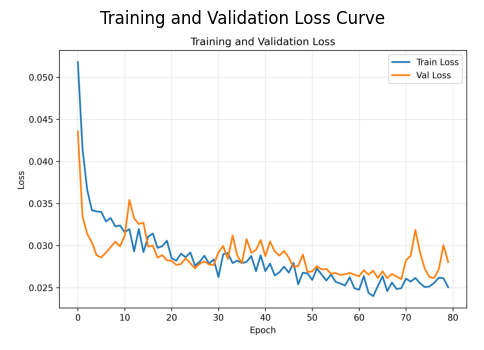

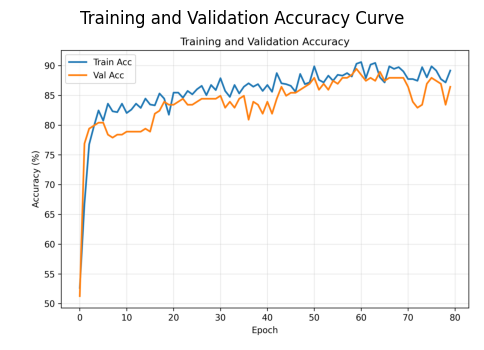

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Load the combined image
img = Image.open("/content/drive/MyDrive/training_history_improved.png")

# Get dimensions
width, height = img.size

# Since your plot layout was (2 x 2), we can crop each quadrant:
# Top-left (Train/Val Loss)
loss_img = img.crop((0, 0, width/2, height/2))

# Top-right (Train/Val Accuracy)
acc_img = img.crop((width/2, 0, width, height/2))

# Bottom-left (Learning Rate)
lr_img = img.crop((0, height/2, width/2, height))

# Bottom-right (Overfitting Monitor)
overfit_img = img.crop((width/2, height/2, width, height))

# Display them separately
plt.figure(figsize=(6,5))
plt.imshow(loss_img)
plt.axis('off')
plt.title("Training and Validation Loss Curve")
plt.show()

plt.figure(figsize=(6,5))
plt.imshow(acc_img)
plt.axis('off')
plt.title("Training and Validation Accuracy Curve")
plt.show()

